## 1

In [5]:
import numpy as np
from sklearn.datasets import load_diabetes

# (1) 사이킷런에서 당뇨병 데이터 가져오기
diabetes = load_diabetes()
df_X = diabetes.data
df_y = diabetes.target

# (2) 입력 데이터 X를 넘파이 배열로 준비하기
X = np.array(df_X)

# (3) 예측할 정답 데이터 y를 넘파이 배열로 준비하기
y = np.array(df_y)

# 데이터 모양 확인해보기
print(X.shape, y.shape)

(442, 10) (442,)


In [6]:
from sklearn.model_selection import train_test_split

# 모의고사(Train)와 실전시험(Test) 데이터를 8:2 비율로 쪼개기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(353, 10) (89, 10)


In [7]:
# 10개의 특성에 맞게 랜덤한 가중치 W(10개)와 b(1개) 설정
W = np.random.rand(10)
b = np.random.rand()

# 선형회귀 모델 함수 정의 (y = WX + b)
def model(X, W, b):
    predictions = 0
    for i in range(10):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [8]:
# 제곱의 평균을 내는 MSE 함수
def MSE(a, b):
    mse = ((a - b) ** 2).mean()
    return mse

# 모델의 오차 점수(벌점)를 계산하는 loss 함수
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [9]:
# 미분을 통해 가중치들의 변화량(기울기)을 구하는 함수
def gradient(X, W, b, y):
    N = len(y)
    predictions = model(X, W, b)
    
    # 공식에 따른 미분값 계산
    dW = 1/N * 2 * X.T.dot(predictions - y)
    db = 1/N * 2 * (predictions - y).sum()
    
    return dW, db

In [10]:
# (8) 하이퍼 파라미터인 학습률 설정하기
LEARNING_RATE = 0.1

# (9) 1000번 반복하면서 모델 학습시키기
losses = []

for i in range(1, 1001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    
    if i % 100 == 0:
        print(f"Iteration {i} : Loss {L:.4f}")

Iteration 100 : Loss 5377.3287
Iteration 200 : Loss 4875.6242
Iteration 300 : Loss 4502.5338
Iteration 400 : Loss 4221.3951
Iteration 500 : Loss 4006.4158
Iteration 600 : Loss 3839.4062
Iteration 700 : Loss 3707.4986
Iteration 800 : Loss 3601.5552
Iteration 900 : Loss 3515.0560
Iteration 1000 : Loss 3443.3212


In [11]:
# 숨겨둔 실전 시험용 데이터(X_test)를 넣어 최종 MSE 점수 확인
test_loss = loss(X_test, W, b, y_test)
print(f"최종 Test 데이터 MSE 손실값: {test_loss:.4f}")

최종 Test 데이터 MSE 손실값: 3090.7438


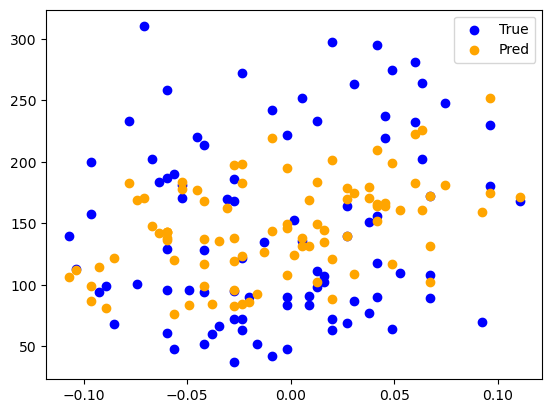

In [12]:
import matplotlib.pyplot as plt

# 실전 데이터의 최종 예측값 계산
test_prediction = model(X_test, W, b)

# 첫 번째 특성(X_test[:, 0])을 기준으로 실제 정답(파란색)과 AI 예측값(주황색) 그리기
plt.scatter(X_test[:, 0], y_test, label="True", color="blue")
plt.scatter(X_test[:, 0], test_prediction, label="Pred", color="orange")
plt.legend()
plt.show()

## 2

In [14]:
import pandas as pd

# 캐글 자전거 대여 데이터 불러오기
train = pd.read_csv('~/data/data/bike-sharing-demand/train.csv')

# 데이터 첫 5행 확인하기
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [15]:
# 문자열인 날짜 데이터를 진짜 날짜/시간 자료형으로 변환
train['datetime'] = pd.to_datetime(train['datetime'])

# 연, 월, 일, 시, 분, 초 6가지 컬럼 새로 만들기
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

# 새 컬럼들이 잘 들어갔는지 확인
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


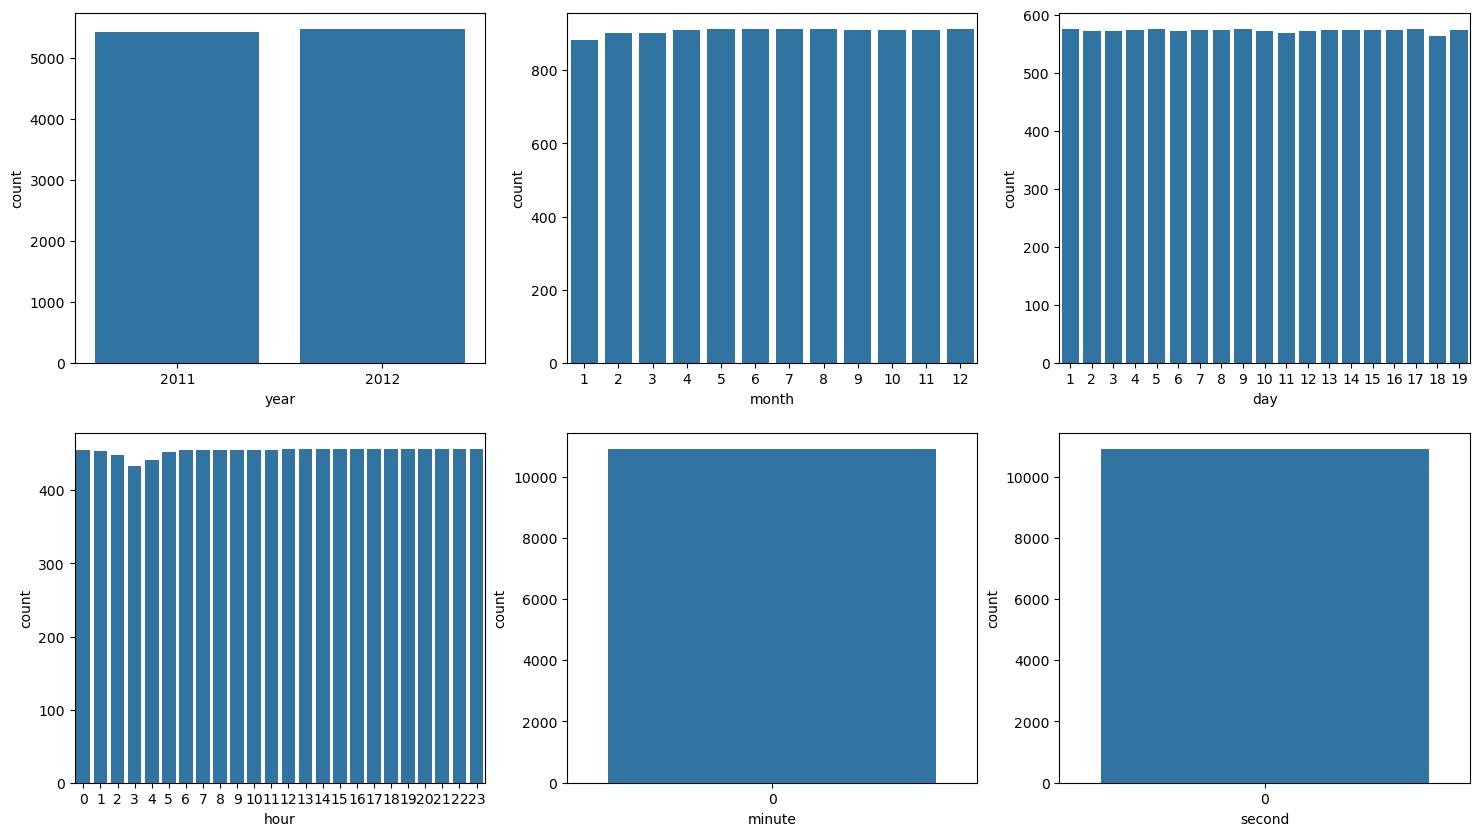

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2행 3열짜리 그래프 그릴 준비하기
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 각각의 방에 연, 월, 일, 시, 분, 초 막대그래프 그리기
sns.countplot(x='year', data=train, ax=axes[0, 0])
sns.countplot(x='month', data=train, ax=axes[0, 1])
sns.countplot(x='day', data=train, ax=axes[0, 2])
sns.countplot(x='hour', data=train, ax=axes[1, 0])
sns.countplot(x='minute', data=train, ax=axes[1, 1])
sns.countplot(x='second', data=train, ax=axes[1, 2])

# 그래프 화면에 보여주기
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

# 정답 유출이나 불필요한 컬럼(분, 초 등)은 제외하고 문제지 X 만들기
X_features = ['year', 'month', 'day', 'hour', 'workingday', 'holiday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']
X = train[X_features]

# 우리가 맞춰야 하는 정답 자전거 대여량 y 세팅
y = train['count']

# 훈련용(Train)과 시험용(Test) 데이터를 8:2 비율로 쪼개기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(8708, 11) (2178, 11)


In [18]:
from sklearn.linear_model import LinearRegression

# 사이킷런에서 제공하는 선형회귀 모델 가져오기
model = LinearRegression()

# 훈련 데이터로 AI 단 한 줄만에 학습시키기
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 학습된 AI에게 시험지(X_test)를 주고 대여량 예측해보라고 하기
predictions = model.predict(X_test)

# 실제 정답(y_test)과 비교해서 오차 점수 구하기
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"최종 MSE 손실값: {mse:.4f}")
print(f"최종 RMSE 손실값: {rmse:.4f}")

최종 MSE 손실값: 19947.3766
최종 RMSE 손실값: 141.2352


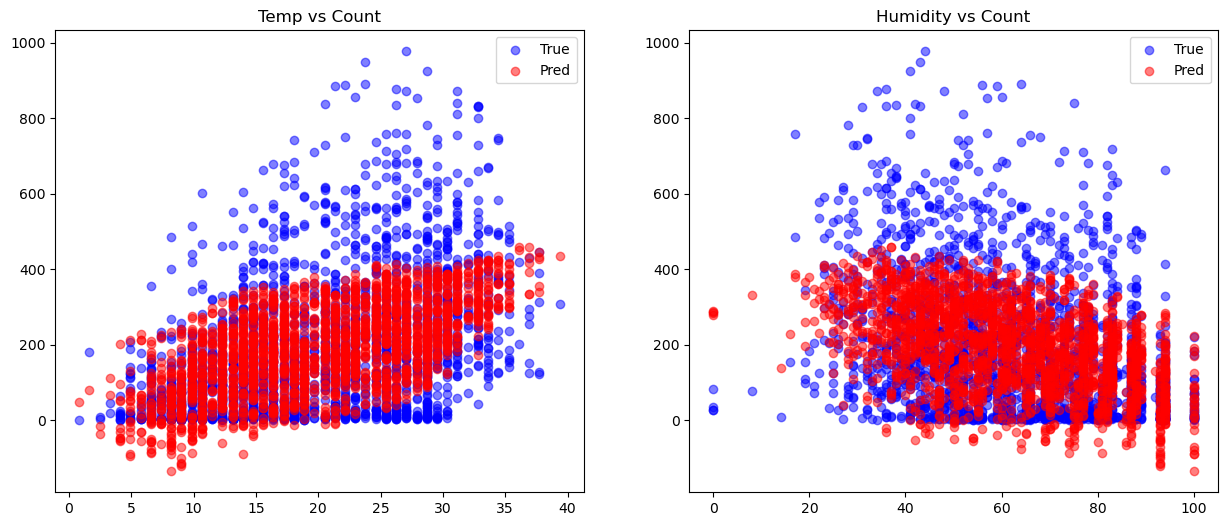

In [20]:
# 1행 2열짜리 그래프 그릴 준비하기
plt.figure(figsize=(15, 6))

# 첫 번째 방: x축은 온도(temp), y축은 대여량(count)
plt.subplot(1, 2, 1)
plt.scatter(X_test['temp'], y_test, label="True", color="blue", alpha=0.5)
plt.scatter(X_test['temp'], predictions, label="Pred", color="red", alpha=0.5)
plt.title("Temp vs Count")
plt.legend()

# 두 번째 방: x축은 습도(humidity), y축은 대여량(count)
plt.subplot(1, 2, 2)
plt.scatter(X_test['humidity'], y_test, label="True", color="blue", alpha=0.5)
plt.scatter(X_test['humidity'], predictions, label="Pred", color="red", alpha=0.5)
plt.title("Humidity vs Count")
plt.legend()

plt.show()